# Date time

## conversion

- Convert string to datetime: `pd.to_datetime(df['timestamp'])`
- Extract date only (removes time portion): `df['timestamp'].dt.date`
- Extract individual components using `.dt` accessor
    - `df['timestamp'].dt.year`
    - `df['timestamp'].dt.month`
    - `df['timestamp'].dt.day`
    - `df['timestamp'].dt.hour`
    - `df['timestamp'].dt.minute`
    - `df['timestamp'].dt.day_name()  `
    - `df['timestamp'].dt.quarter`
- checking the property of a date returning a boolean
    - `dt.is_month_end`
    - `dt.is_quarter_end`
    - `dt.is_month_start`

In [1]:
import pandas as pd

# Sample data
df = pd.DataFrame({
    'timestamp': ['2024-01-15 14:30:25', '2024-02-20 09:15:30', '2024-03-10 18:45:12']
})

df['timestamp']=pd.to_datetime(df['timestamp'])
print(df['timestamp'].dt.date)

0    2024-01-15
1    2024-02-20
2    2024-03-10
Name: timestamp, dtype: object


In [2]:
# Return a series with string dates
df['timestamp'].dt.strftime('%d/%m/%y')


0    15/01/24
1    20/02/24
2    10/03/24
Name: timestamp, dtype: str

## rolling window

- two usages of `.rolling()`
    - `df['sales'].rolling(window=7).apply(lambda x: x.max() - x.min())`
    - `df['sales'].rolling(window=7,center=True).mean()`
- time delta
    - `df['date'] - df['date'].iloc[0]).dt.days`
    - using `.diff()`: `df['date'].diff().dt.days`
- changes
    - using `.diff()`: `df['sales'].diff(periods=2)`
    - downward shifting: `df['p']-df['p'].shift(1)`
- for filling NA
    - `.fillna(method='ffill')`

Key Functions Summary

| Function | Purpose | Example |
|----------|---------|---------|
| `.diff()` | Absolute difference from previous row | `df['price'].diff()` |
| `.diff(n)` | Difference from n rows back | `df['price'].diff(3)` |
| `.pct_change()` | Percentage change from previous | `df['price'].pct_change()` |
| `.shift(n)` | Move values up/down by n rows | `df['price'].shift(1)` |
| `.cumsum()` | Cumulative sum | `df['change'].cumsum()` |
| `.cumprod()` | Cumulative product | `(1 + returns).cumprod()` |
| `dt.days` | Extract days from timedelta | `(date2 - date1).dt.days` |
| `dt.total_seconds()` | Total seconds in timedelta | `(date2 - date1).dt.total_seconds()` |


## Resampling
group date entries by some interval (yearly, monthly, weekly) and then aggregate the values at that interval


In [3]:
import pandas as pd
url = 'https://github.com/mattharrison/datasets'+\
    '/raw/master/data/alta-noaa-1980-2019.csv'
alta_df = pd.read_csv(url)
dates = pd.to_datetime(alta_df.DATE)
snow =alta_df['SNOW'].rename(dates)
snow.resample('YE').mean().head(10)

1980-12-31    1.553279
1981-12-31    1.886301
1982-12-31    2.327397
1983-12-31    2.478082
1984-12-31    1.857377
1985-12-31    1.354420
1986-12-31    1.668451
1987-12-31    0.734637
1988-12-31    1.140625
1989-12-31    0.930556
Freq: YE-DEC, Name: SNOW, dtype: float64

In [4]:
# monthly percent
season2017 = snow.loc['2016-10':'2017-05']
season2017.resample('QE').sum().div(season2017.sum()).mul(100)


2016-12-31    27.642601
2017-03-31    55.783805
2017-06-30    16.573594
Freq: QE-DEC, Name: SNOW, dtype: float64

# time series

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
def download_and_modify_url(url, local_filename):
# Download the file from the URL
    urllib.request.urlretrieve(url, local_filename)
    with open(local_filename, 'r') as file:
        lines = file.readlines()
    with open(local_filename, 'w') as file:
        for i, line in enumerate(lines):
            if i <34 or i == 35:
                continue
            file.write(line)
url = 'https://github.com/mattharrison/datasets/raw/master'\
        '/data/dirtydevil.txt'

local_filename = 'data/devilclean.txt'
download_and_modify_url(url, local_filename)

df = pd.read_csv('data/devilclean.txt',sep='\t')
def tweak_river(df_):
    return (df_.assign(datetime=pd.to_datetime(df_.datetime))\
            .rename(columns={'144166_00060': 'cfs','144167_00065': 'gage_height'})\
            .set_index('datetime')\
            .loc[:, ['agency_cd', 'site_no', 'tz_cd', 'cfs', 'gage_height'] ])
dd = tweak_river(df)
dd.head(5)

C:\Users\xiang\AppData\Local\Temp\ipykernel_13464\1150362422.py:20: DtypeWarning: Columns (0: 144167_00065_cd) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/devilclean.txt',sep='\t')


,agency_cd,site_no,tz_cd,cfs,gage_height
datetime,,,,,
2001-05-07 01:00:00,USGS,9333500,MDT,71.0,NaN
2001-05-07 01:15:00,USGS,9333500,MDT,71.0,NaN
2001-05-07 01:30:00,USGS,9333500,MDT,71.0,NaN
2001-05-07 01:45:00,USGS,9333500,MDT,70.0,NaN
2001-05-07 02:00:00,USGS,9333500,MDT,70.0,NaN


<Axes: xlabel='datetime'>

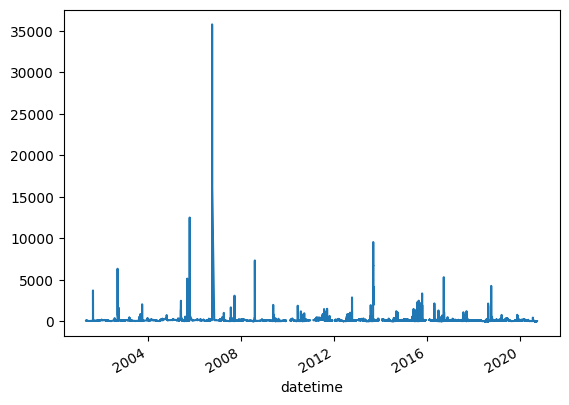

In [6]:
import matplotlib.pyplot as plt
dd['cfs'].plot()

In [7]:
dd.cfs.describe()

count    493124.000000
mean        104.460537
std         477.341329
min           0.000000
25%          34.700000
50%          81.000000
75%         115.000000
max       35800.000000
Name: cfs, dtype: float64

<Axes: xlabel='datetime'>

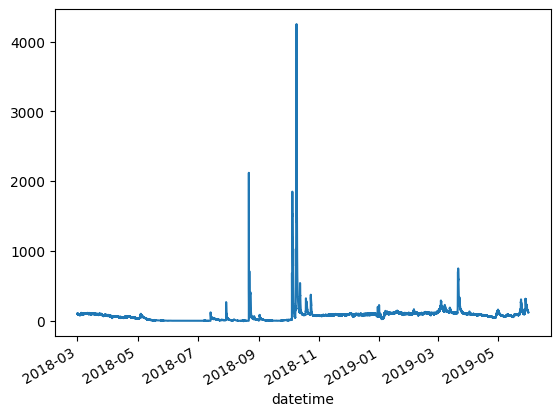

In [8]:
dd.sort_index().cfs.loc['2018/3':'2019/5'].plot()

In [9]:
dd.index

DatetimeIndex(['2001-05-07 01:00:00', '2001-05-07 01:15:00',
               '2001-05-07 01:30:00', '2001-05-07 01:45:00',
               '2001-05-07 02:00:00', '2001-05-07 02:15:00',
               '2001-05-07 02:30:00', '2001-05-07 02:45:00',
               '2001-05-07 03:00:00', '2001-05-07 03:15:00',
               ...
               '2020-09-28 07:15:00', '2020-09-28 07:30:00',
               '2020-09-28 07:45:00', '2020-09-28 08:00:00',
               '2020-09-28 08:15:00', '2020-09-28 08:30:00',
               '2020-09-28 08:45:00', '2020-09-28 09:00:00',
               '2020-09-28 09:15:00', '2020-09-28 09:30:00'],
              dtype='datetime64[us]', name='datetime', length=539305, freq=None)

## explore seasonality

<Axes: xlabel='datetime'>

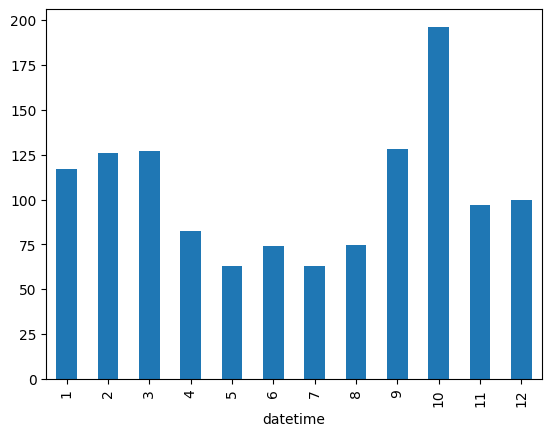

In [10]:
dd.groupby(dd.index.month)['cfs'].describe()['mean'].plot.bar()